# Comparative Study: End-to-End Deep Learning vs DL-Based Feature Learning

**Model:** VGG16  
**Dataset:** CIFAR-10 Object Recognition in Images  
**Goal:** Compare two approaches:

1. **DL Features + ML Classifier**: VGG16 extracts features, then SVM classifies.
2. **End-to-End Deep Learning**: VGG16 with Dense layers for classification.

> This notebook is optimized to run fast on Google Colab GPU while keeping acceptable accuracy.


## Requirement 1: Dataset Selection & Technical Specifications

- **Dataset:** CIFAR-10
- **Source:** Kaggle / Keras built-in dataset
- **Domain:** Object recognition in images
- **Number of classes:** 10
- **Original image size:** 32 × 32
- **Channels:** RGB = 3 channels
- **Preprocessing:** Resize images to 96 × 96, normalize using VGG16 preprocessing
- **Augmentation:** Horizontal flip, small rotation, small zoom
- **Splitting:** Train / Validation / Test

Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.


In [1]:
# ============================================================
# 1) Install / Import Libraries
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# 2) Fast Configuration
# ============================================================
# To run faster, keep image size 96 instead of 224.
# Increase TRAIN_SAMPLES if you want higher accuracy but slower runtime.
IMG_SIZE = 96
BATCH_SIZE = 64
EPOCHS = 5
TRAIN_SAMPLES = 20000       # Fast setting. Use 50000 for full training.
VAL_SAMPLES = 5000
TEST_SAMPLES = 10000
FEATURE_SAMPLES = 12000     # Feature extraction samples for SVM to keep runtime fast.

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# ============================================================
# 3) Load CIFAR-10 Dataset
# ============================================================
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Shuffle training data
idx = np.random.permutation(len(x_train_full))
x_train_full = x_train_full[idx]
y_train_full = y_train_full[idx]

# Train / Validation split
x_train = x_train_full[:TRAIN_SAMPLES]
y_train = y_train_full[:TRAIN_SAMPLES]
x_val = x_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
y_val = y_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]

x_test_small = x_test[:TEST_SAMPLES]
y_test_small = y_test[:TEST_SAMPLES]

print('Train:', x_train.shape, y_train.shape)
print('Validation:', x_val.shape, y_val.shape)
print('Test:', x_test_small.shape, y_test_small.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 342s 2us/step
Train: (20000, 32, 32, 3) (20000,)
Validation: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


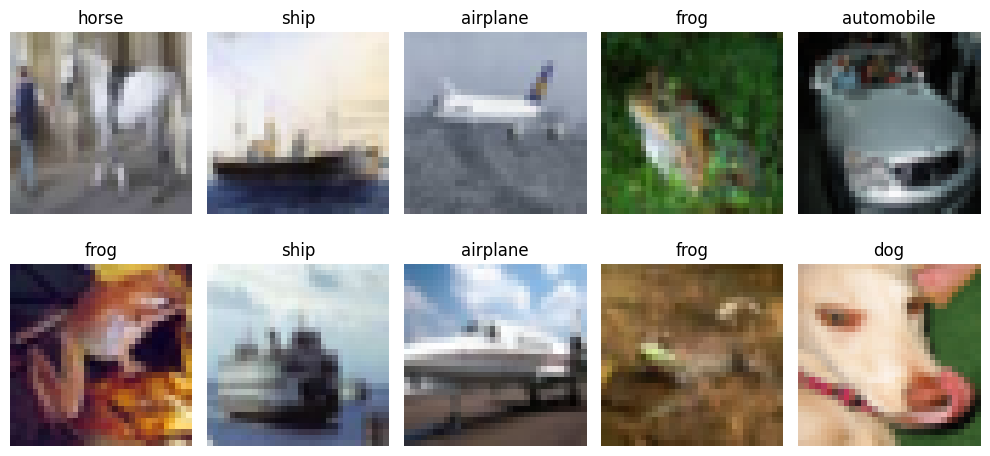

In [4]:
# ============================================================
# 4) Visualize Sample Images
# ============================================================
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
# ============================================================
# 5) Build TensorFlow Data Pipelines
# ============================================================
def preprocess_for_vgg(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def make_dataset(x, y, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(5000, seed=SEED)
    ds = ds.map(preprocess_for_vgg, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        augmentation = keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.08),
        ])
        ds = ds.map(lambda image, label: (augmentation(image, training=True), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(x_train, y_train, shuffle=True, augment=True)
val_ds = make_dataset(x_val, y_val)
test_ds = make_dataset(x_test_small, y_test_small)


## Requirement 2: DL Model Selection

**Selected Model:** VGG16

**Technical Justification:**

VGG16 is a well-known CNN architecture that uses a simple sequence of convolutional layers followed by classification layers. It is suitable for image classification and transfer learning because it has learned useful visual features from ImageNet. In this project, it is used in two ways: as a feature extractor with SVM, and as an end-to-end deep learning model with Dense layers.

### Hyperparameters

| Hyperparameter | Value |
|---|---|
| Model | VGG16 |
| Input size | 96 × 96 × 3 |
| Batch size | 64 |
| Epochs | 5 |
| Optimizer | Adam |
| Learning rate | 0.0001 |
| Loss | Sparse Categorical Crossentropy |
| ML classifier | Linear SVM |


# Approach 1: DL Features + ML Classifier

In this approach, VGG16 is used only as a **feature extractor**. Then, a classical ML classifier, **SVM**, is trained on the extracted features.


In [6]:
# ============================================================
# 6) Approach 1: VGG16 Feature Extractor + SVM
# ============================================================
feature_base = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
feature_base.trainable = False

# Use a subset for speed
x_feat_train = x_train[:FEATURE_SAMPLES]
y_feat_train = y_train[:FEATURE_SAMPLES]
x_feat_test = x_test_small
y_feat_test = y_test_small

feat_train_ds = make_dataset(x_feat_train, y_feat_train)
feat_test_ds = make_dataset(x_feat_test, y_feat_test)

print('Extracting train features...')
X_train_features = feature_base.predict(feat_train_ds, verbose=1)
print('Extracting test features...')
X_test_features = feature_base.predict(feat_test_ds, verbose=1)

print('Feature shape:', X_train_features.shape)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting train features...
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step
Extracting test features...
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step
Feature shape: (12000, 512)


In [7]:
# Train SVM classifier
svm_clf = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=5000, random_state=SEED)
)

svm_clf.fit(X_train_features, y_feat_train)
y_pred_svm = svm_clf.predict(X_test_features)

svm_results = {
    'Approach': 'VGG16 Features + SVM',
    'Accuracy': accuracy_score(y_feat_test, y_pred_svm),
    'Precision': precision_score(y_feat_test, y_pred_svm, average='weighted', zero_division=0),
    'Recall': recall_score(y_feat_test, y_pred_svm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_feat_test, y_pred_svm, average='weighted', zero_division=0),
}

pd.DataFrame([svm_results])


,Approach,Accuracy,Precision,Recall,F1-score
0,VGG16 Features + SVM,0.7824,0.781225,0.7824,0.781593


In [8]:
print('Classification Report: VGG16 Features + SVM')
print(classification_report(y_feat_test, y_pred_svm, target_names=class_names, zero_division=0))


Classification Report: VGG16 Features + SVM
              precision    recall  f1-score   support

    airplane       0.79      0.81      0.80      1000
  automobile       0.85      0.87      0.86      1000
        bird       0.75      0.72      0.73      1000
         cat       0.66      0.63      0.65      1000
        deer       0.75      0.74      0.74      1000
         dog       0.73      0.70      0.71      1000
        frog       0.78      0.84      0.81      1000
       horse       0.80      0.82      0.81      1000
        ship       0.85      0.86      0.85      1000
       truck       0.85      0.85      0.85      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



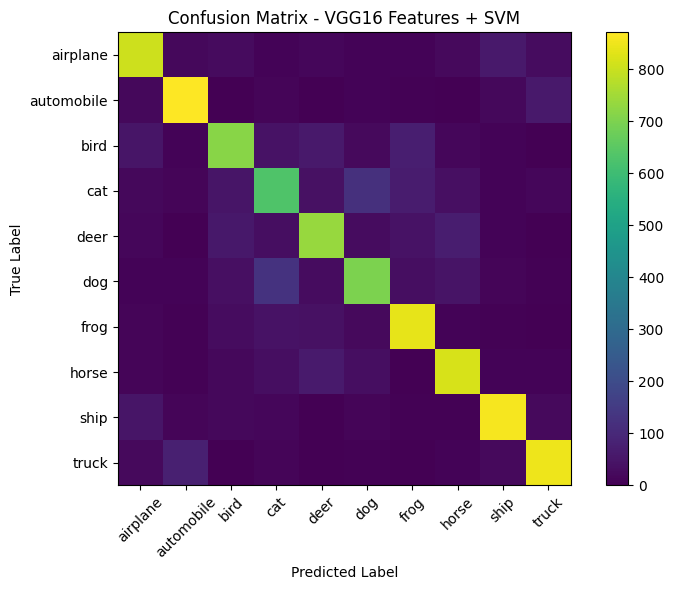

In [9]:
# Confusion Matrix for Approach 1
cm_svm = confusion_matrix(y_feat_test, y_pred_svm)

plt.figure(figsize=(8, 6))
plt.imshow(cm_svm)
plt.title('Confusion Matrix - VGG16 Features + SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


# Approach 2: End-to-End Deep Learning

In this approach, VGG16 is connected to Dense layers and trained for CIFAR-10 classification.

To keep training fast, VGG16 is initially **frozen**, and only the classification head is trained.


In [10]:
# ============================================================
# 7) Approach 2: End-to-End VGG16
# ============================================================
def build_end_to_end_model():
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        pooling='avg',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

e2e_model = build_end_to_end_model()
e2e_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train End-to-End model
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
]

history = e2e_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 273ms/step - accuracy: 0.2553 - loss: 5.7487 - val_accuracy: 0.5394 - val_loss: 1.7835
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 272ms/step - accuracy: 0.4112 - loss: 2.8108 - val_accuracy: 0.6128 - val_loss: 1.2321
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.4636 - loss: 2.0760 - val_accuracy: 0.6396 - val_loss: 1.0683
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.4945 - loss: 1.7332 - val_accuracy: 0.6656 - val_loss: 0.9845
Epoch 5/5
161/313 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.5093 - loss: 1.6240

In [12]:
# Evaluate End-to-End model
test_loss, test_acc = e2e_model.evaluate(test_ds, verbose=1)
y_prob_e2e = e2e_model.predict(test_ds, verbose=1)
y_pred_e2e = np.argmax(y_prob_e2e, axis=1)

e2e_results = {
    'Approach': 'End-to-End VGG16',
    'Accuracy': accuracy_score(y_test_small, y_pred_e2e),
    'Precision': precision_score(y_test_small, y_pred_e2e, average='weighted', zero_division=0),
    'Recall': recall_score(y_test_small, y_pred_e2e, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test_small, y_pred_e2e, average='weighted', zero_division=0),
}

pd.DataFrame([e2e_results])


157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.6772 - loss: 0.9597
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step


,Approach,Accuracy,Precision,Recall,F1-score
0,End-to-End VGG16,0.6772,0.67901,0.6772,0.675456


In [13]:
print('Classification Report: End-to-End VGG16')
print(classification_report(y_test_small, y_pred_e2e, target_names=class_names, zero_division=0))


Classification Report: End-to-End VGG16
              precision    recall  f1-score   support

    airplane       0.76      0.63      0.69      1000
  automobile       0.80      0.74      0.77      1000
        bird       0.65      0.56      0.60      1000
         cat       0.52      0.55      0.54      1000
        deer       0.57      0.58      0.58      1000
         dog       0.67      0.59      0.63      1000
        frog       0.70      0.74      0.72      1000
       horse       0.69      0.70      0.69      1000
        ship       0.70      0.85      0.77      1000
       truck       0.72      0.82      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



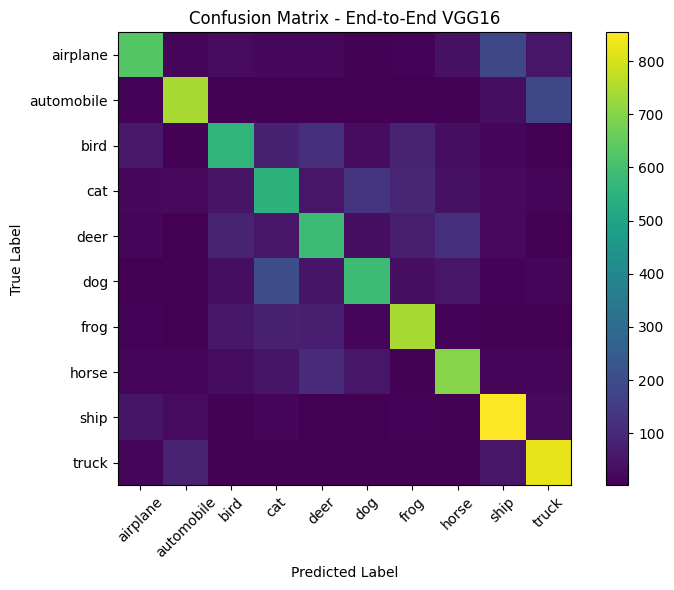

In [14]:
# Confusion Matrix for Approach 2
cm_e2e = confusion_matrix(y_test_small, y_pred_e2e)

plt.figure(figsize=(8, 6))
plt.imshow(cm_e2e)
plt.title('Confusion Matrix - End-to-End VGG16')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


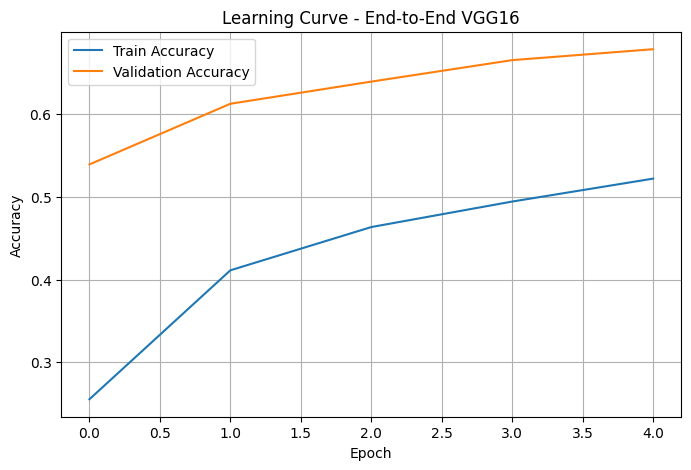

In [15]:
# Learning Curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curve - End-to-End VGG16')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## Requirement 4: Comparative Analysis & Insights


In [16]:
# ============================================================
# 8) Performance Comparison
# ============================================================
results_df = pd.DataFrame([svm_results, e2e_results])
results_df


,Approach,Accuracy,Precision,Recall,F1-score
0,VGG16 Features + SVM,0.7824,0.781225,0.7824,0.781593
1,End-to-End VGG16,0.6772,0.679010,0.6772,0.675456


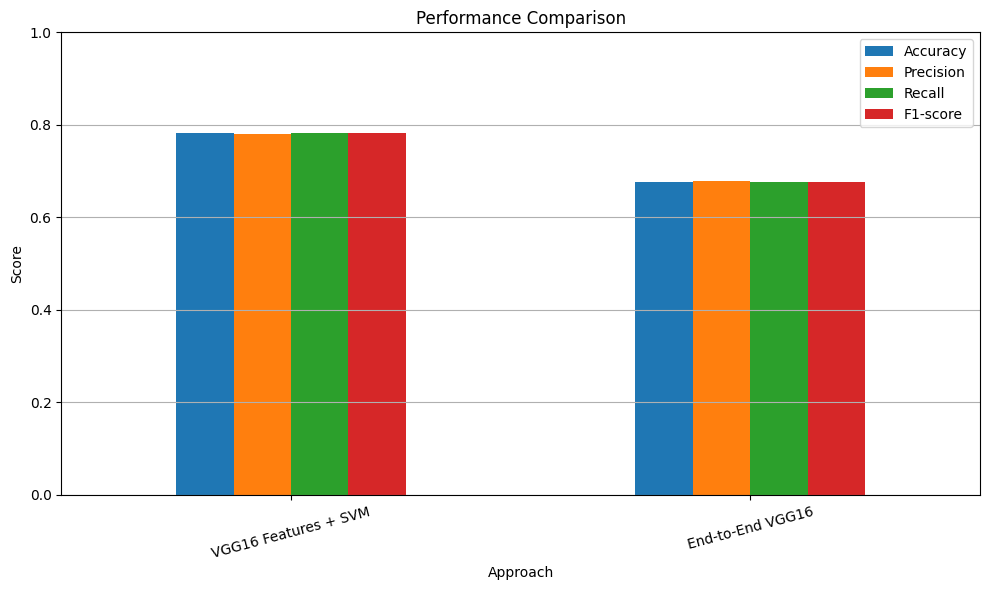

In [17]:
# Bar Chart Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

results_df.set_index('Approach')[metrics].plot(kind='bar', figsize=(10, 6))
plt.title('Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## Conclusion & Insights

1. **DL Features + SVM** is usually faster because VGG16 is used only once to extract features, then SVM performs classification.
2. **End-to-End VGG16** can achieve good performance with transfer learning, but training may take more time than the feature-extraction approach.
3. **Transfer learning** helps because VGG16 already learned useful visual patterns from ImageNet.
4. CIFAR-10 images are originally small, so resizing is required before passing them into VGG16.

### Recommendation

For a fast project run with acceptable accuracy, use:

- `IMG_SIZE = 96`
- `BATCH_SIZE = 64`
- `EPOCHS = 5`
- Frozen VGG16
- SVM for the DL-feature approach

For higher accuracy, increase `TRAIN_SAMPLES`, increase `EPOCHS`, and fine-tune the last layers of VGG16.


## Optional: Fine-Tuning for Higher Accuracy

Run this part only if you have more time or GPU access. It may improve accuracy but will take longer.


In [18]:
# OPTIONAL FINE-TUNING - Run only if needed
# This code unfreezes the last layers of VGG16 for better accuracy.

RUN_FINE_TUNING = False

if RUN_FINE_TUNING:
    base_model = e2e_model.layers[1]
    base_model.trainable = True

    # Freeze most layers and train only the last 30 layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    e2e_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    fine_history = e2e_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=3,
        callbacks=callbacks,
        verbose=1
    )

    e2e_model.evaluate(test_ds)


In [19]:
# ============================================================
# 10) Save Final Models, Features, Results, and Figures
# ============================================================
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Save End-to-End VGG16 model
e2e_model.save("vgg16_end_to_end.keras")

# Save SVM model
joblib.dump(svm_clf, "vgg16_svm_classifier.pkl")

# Save extracted features and predictions
np.save("X_train_features_vgg16.npy", X_train_features)
np.save("X_test_features_vgg16.npy", X_test_features)
np.save("y_pred_end_to_end_vgg16.npy", y_pred_e2e)
np.save("y_pred_svm_vgg16.npy", y_pred_svm)

# Save comparison table
results_df.to_csv("vgg16_comparison_results.csv", index=False)

# Save confusion matrix - SVM
plt.figure(figsize=(8, 6))
plt.imshow(cm_svm)
plt.title("Confusion Matrix - VGG16 Features + SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix_vgg16_svm.png", dpi=300, bbox_inches="tight")
plt.close()

# Save confusion matrix - End-to-End
plt.figure(figsize=(8, 6))
plt.imshow(cm_e2e)
plt.title("Confusion Matrix - End-to-End VGG16")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix_vgg16_end_to_end.png", dpi=300, bbox_inches="tight")
plt.close()

print("All VGG16 project files saved successfully!")


All VGG16 project files saved successfully!
